
# CSE498R Final Thesis Notebook — Stage 1  
**Topic:** Selective Instance Segmentation + Inpainting for Object/Person Removal

This notebook is the **stronger final-stage starting point** for your thesis work.

## Goal of this notebook
In this first stage, we will build the **data foundation** properly:
1. set up the Colab environment  
2. mount Google Drive  
3. create a clean folder structure  
4. define preprocessing rules  
5. resize images correctly without distortion  
6. clean masks  
7. filter weak samples  
8. create train / val / test splits without leakage  

## Why this stage matters
Your teacher asked for:
- stronger architecture
- better dataset design
- proper preprocessing
- more serious experimental setup

So before building the final segmentation + inpainting pipeline, we must first make the dataset and preprocessing pipeline strong.

---
**Recommended working flow**
- Run all cells in order
- Save outputs in Drive
- Check sample visualizations carefully
- Only then move to training / inference notebook


In [1]:
# ============================================================
# CELL 1: Install required packages
# ============================================================
# Notes:
# - We keep versions reasonably stable for Colab.
# - If a package already exists, Colab will usually skip or update it.
# - Restart runtime only if Colab asks for it.

%%capture
!pip -q install ultralytics opencv-python albumentations simple-lama-inpainting scikit-image tqdm

print("Packages installed successfully.")


In [2]:
# ============================================================
# CELL 2: Mount Google Drive and create base paths
# ============================================================

from google.colab import drive
drive.mount('/content/drive')

import os
from pathlib import Path

PROJECT_ROOT = Path("/content/drive/MyDrive/CSE498R_Final_Thesis")
DATA_ROOT = PROJECT_ROOT / "data"
RAW_ROOT = DATA_ROOT / "raw"
PROCESSED_ROOT = DATA_ROOT / "processed"
SPLIT_ROOT = DATA_ROOT / "splits"
VIS_ROOT = PROJECT_ROOT / "visualizations"
MODEL_ROOT = PROJECT_ROOT / "models"
RESULT_ROOT = PROJECT_ROOT / "results"

for p in [PROJECT_ROOT, DATA_ROOT, RAW_ROOT, PROCESSED_ROOT, SPLIT_ROOT, VIS_ROOT, MODEL_ROOT, RESULT_ROOT]:
    p.mkdir(parents=True, exist_ok=True)

print("Project folders created.")
print("PROJECT_ROOT:", PROJECT_ROOT)


Mounted at /content/drive
Project folders created.
PROJECT_ROOT: /content/drive/MyDrive/CSE498R_Final_Thesis



## Dataset strategy for the final thesis

For now, this notebook supports a **generic image + mask dataset** layout.

### Expected raw dataset layout
You can place files like this inside `RAW_ROOT`:

```text
raw/
 ├── images/
 │    ├── 0001.jpg
 │    ├── 0002.jpg
 │    └── ...
 └── masks/
      ├── 0001.png
      ├── 0002.png
      └── ...
```

### Important rule
- image name and mask name must match by stem  
  example:
  - image: `0001.jpg`
  - mask: `0001.png`

### Mask meaning
- object/person area = white / non-zero
- background = black / zero

Later, if needed, we can extend this to:
- COCO JSON
- Open Images masks
- synthetic pasted dataset
- multiple instance masks per image


In [3]:
# ============================================================
# CELL 3: Core imports
# ============================================================

import json
import random
import math
import shutil
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image
from tqdm.auto import tqdm
from sklearn.model_selection import train_test_split
from skimage.morphology import remove_small_objects, remove_small_holes

random.seed(42)
np.random.seed(42)

print("Imports ready.")


Imports ready.


In [4]:
# ============================================================
# CELL 4: Configuration
# ============================================================

CFG = {
    "target_long_side": 1280,
    "min_short_side": 768,
    "local_crop_size": 768,

    "min_mask_area_ratio": 0.02,
    "max_mask_area_ratio": 0.35,

    "min_component_pixels": 128,
    "min_hole_pixels": 128,

    "base_dilation_small": 8,
    "base_dilation_medium": 16,
    "base_dilation_large": 28,

    "train_ratio": 0.70,
    "val_ratio": 0.15,
    "test_ratio": 0.15,

    "image_exts": [".jpg", ".jpeg", ".png", ".webp"],
    "mask_exts": [".png", ".jpg", ".jpeg"],

    "num_preview_samples": 8
}

assert abs(CFG["train_ratio"] + CFG["val_ratio"] + CFG["test_ratio"] - 1.0) < 1e-8
print(json.dumps(CFG, indent=2))


{
  "target_long_side": 1280,
  "min_short_side": 768,
  "local_crop_size": 768,
  "min_mask_area_ratio": 0.02,
  "max_mask_area_ratio": 0.35,
  "min_component_pixels": 128,
  "min_hole_pixels": 128,
  "base_dilation_small": 8,
  "base_dilation_medium": 16,
  "base_dilation_large": 28,
  "train_ratio": 0.7,
  "val_ratio": 0.15,
  "test_ratio": 0.15,
  "image_exts": [
    ".jpg",
    ".jpeg",
    ".png",
    ".webp"
  ],
  "mask_exts": [
    ".png",
    ".jpg",
    ".jpeg"
  ],
  "num_preview_samples": 8
}


In [5]:
# ============================================================
# CELL 5: Helper functions for image and mask processing
# ============================================================

def list_files(folder, allowed_exts):
    folder = Path(folder)
    files = []
    for p in folder.rglob("*"):
        if p.is_file() and p.suffix.lower() in allowed_exts:
            files.append(p)
    return sorted(files)

def load_image_rgb(path):
    img = Image.open(path).convert("RGB")
    return np.array(img)

def load_mask_binary(path):
    mask = Image.open(path).convert("L")
    mask = np.array(mask)
    binary = (mask > 0).astype(np.uint8) * 255
    return binary

def resize_with_aspect_ratio(image, target_long_side=1280, min_short_side=768, is_mask=False):
    h, w = image.shape[:2]

    scale = target_long_side / max(h, w)
    new_w = int(round(w * scale))
    new_h = int(round(h * scale))

    interp = cv2.INTER_NEAREST if is_mask else cv2.INTER_CUBIC
    resized = cv2.resize(image, (new_w, new_h), interpolation=interp)

    h2, w2 = resized.shape[:2]
    short_side = min(h2, w2)

    if short_side < min_short_side:
        scale2 = min_short_side / short_side
        final_w = int(round(w2 * scale2))
        final_h = int(round(h2 * scale2))
        resized = cv2.resize(resized, (final_w, final_h), interpolation=interp)

    return resized

def clean_binary_mask(mask, min_component_pixels=128, min_hole_pixels=128):
    binary = (mask > 0)
    binary = remove_small_objects(binary, min_size=min_component_pixels)
    binary = remove_small_holes(binary, area_threshold=min_hole_pixels)
    binary = binary.astype(np.uint8) * 255
    return binary

def get_mask_area_ratio(mask):
    h, w = mask.shape[:2]
    area = (mask > 0).sum()
    return float(area) / float(h * w)

def get_bbox_from_mask(mask):
    ys, xs = np.where(mask > 0)
    if len(xs) == 0 or len(ys) == 0:
        return None
    x1, y1 = int(xs.min()), int(ys.min())
    x2, y2 = int(xs.max()) + 1, int(ys.max()) + 1
    return [x1, y1, x2, y2]

def bbox_size_category(bbox):
    x1, y1, x2, y2 = bbox
    bw = x2 - x1
    bh = y2 - y1
    area = bw * bh
    if area < 64 * 64:
        return "small"
    elif area < 192 * 192:
        return "medium"
    return "large"

def get_adaptive_dilation(mask, cfg):
    bbox = get_bbox_from_mask(mask)
    if bbox is None:
        return 0
    size_cat = bbox_size_category(bbox)
    if size_cat == "small":
        return cfg["base_dilation_small"]
    elif size_cat == "medium":
        return cfg["base_dilation_medium"]
    return cfg["base_dilation_large"]

def dilate_mask(mask, pixels):
    if pixels <= 0:
        return mask.copy()
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (pixels * 2 + 1, pixels * 2 + 1))
    dilated = cv2.dilate(mask, kernel, iterations=1)
    return dilated

def make_context_ring(core_mask, expanded_mask):
    core = (core_mask > 0).astype(np.uint8)
    expd = (expanded_mask > 0).astype(np.uint8)
    ring = np.clip(expd - core, 0, 1).astype(np.uint8) * 255
    return ring


In [6]:
# ============================================================
# CELL 6: Pair images with masks
# ============================================================

IMAGE_DIR = RAW_ROOT / "images"
MASK_DIR = RAW_ROOT / "masks"

image_files = list_files(IMAGE_DIR, CFG["image_exts"])
mask_files = list_files(MASK_DIR, CFG["mask_exts"])

print("Found images:", len(image_files))
print("Found masks :", len(mask_files))

mask_map = {p.stem: p for p in mask_files}

pairs = []
missing_masks = []

for img_path in image_files:
    stem = img_path.stem
    if stem in mask_map:
        pairs.append((img_path, mask_map[stem]))
    else:
        missing_masks.append(img_path.name)

print("Matched pairs:", len(pairs))
print("Images without mask:", len(missing_masks))
if len(missing_masks) > 0:
    print("Example missing:", missing_masks[:10])


Found images: 200
Found masks : 200
Matched pairs: 200
Images without mask: 0


In [7]:
# ============================================================
# CELL 7: Preprocess and filter dataset
# ============================================================

processed_records = []

PROC_IMG_DIR = PROCESSED_ROOT / "images"
PROC_MASK_DIR = PROCESSED_ROOT / "masks"
PROC_RING_DIR = PROCESSED_ROOT / "context_rings"

for p in [PROC_IMG_DIR, PROC_MASK_DIR, PROC_RING_DIR]:
    p.mkdir(parents=True, exist_ok=True)

for img_path, mask_path in tqdm(pairs, desc="Preprocessing pairs"):
    image = load_image_rgb(img_path)
    mask = load_mask_binary(mask_path)

    image_r = resize_with_aspect_ratio(
        image,
        target_long_side=CFG["target_long_side"],
        min_short_side=CFG["min_short_side"],
        is_mask=False
    )
    mask_r = resize_with_aspect_ratio(
        mask,
        target_long_side=CFG["target_long_side"],
        min_short_side=CFG["min_short_side"],
        is_mask=True
    )

    mask_c = clean_binary_mask(
        mask_r,
        min_component_pixels=CFG["min_component_pixels"],
        min_hole_pixels=CFG["min_hole_pixels"]
    )

    bbox = get_bbox_from_mask(mask_c)
    if bbox is None:
        continue

    mask_ratio = get_mask_area_ratio(mask_c)

    if mask_ratio < CFG["min_mask_area_ratio"]:
        continue
    if mask_ratio > CFG["max_mask_area_ratio"]:
        continue

    dil = get_adaptive_dilation(mask_c, CFG)
    expanded_mask = dilate_mask(mask_c, dil)
    ring_mask = make_context_ring(mask_c, expanded_mask)

    stem = img_path.stem
    out_img = PROC_IMG_DIR / f"{stem}.png"
    out_mask = PROC_MASK_DIR / f"{stem}.png"
    out_ring = PROC_RING_DIR / f"{stem}.png"

    Image.fromarray(image_r).save(out_img)
    Image.fromarray(mask_c).save(out_mask)
    Image.fromarray(ring_mask).save(out_ring)

    x1, y1, x2, y2 = bbox
    h, w = mask_c.shape[:2]

    processed_records.append({
        "id": stem,
        "image_path": str(out_img),
        "mask_path": str(out_mask),
        "ring_path": str(out_ring),
        "height": h,
        "width": w,
        "mask_ratio": mask_ratio,
        "bbox_x1": x1,
        "bbox_y1": y1,
        "bbox_x2": x2,
        "bbox_y2": y2,
        "adaptive_dilation": dil
    })

df = pd.DataFrame(processed_records)
csv_path = PROCESSED_ROOT / "metadata.csv"
df.to_csv(csv_path, index=False)

print("Final kept samples:", len(df))
print("Metadata saved to:", csv_path)
display(df.head())


Preprocessing pairs:   0%|          | 0/200 [00:00<?, ?it/s]

Final kept samples: 104
Metadata saved to: /content/drive/MyDrive/CSE498R_Final_Thesis/data/processed/metadata.csv


,id,image_path,mask_path,ring_path,height,width,mask_ratio,bbox_x1,bbox_y1,bbox_x2,bbox_y2,adaptive_dilation
0,000006_000000006954,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,960,1280,0.310260,0,208,1280,908,28
1,000007_000000009400,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,960,1280,0.343040,0,98,1280,960,28
2,000008_000000009590,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,854,1280,0.305782,0,124,1280,838,28
3,000010_000000013291,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,858,1280,0.200045,59,175,1280,764,28
4,000011_000000013659,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,/content/drive/MyDrive/CSE498R_Final_Thesis/da...,960,1280,0.205387,308,14,1280,960,28


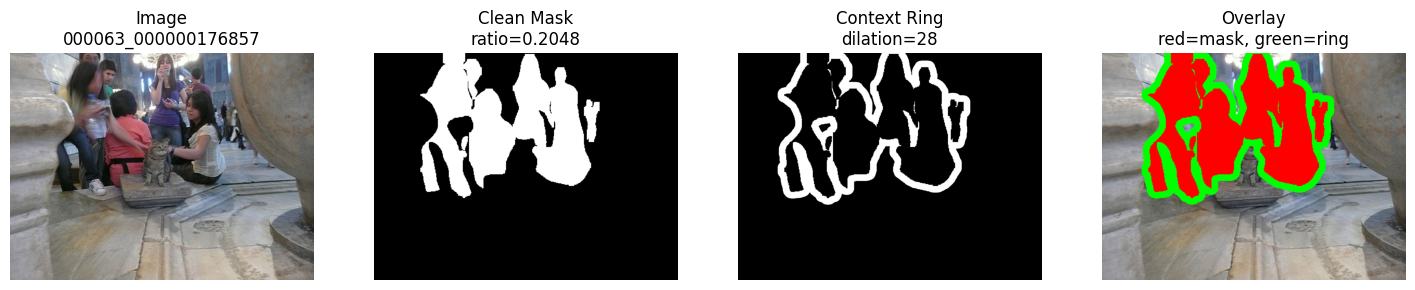

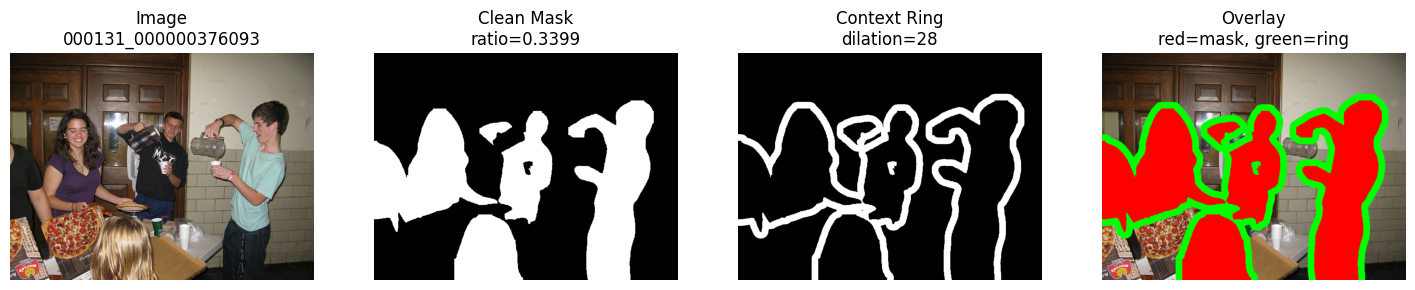

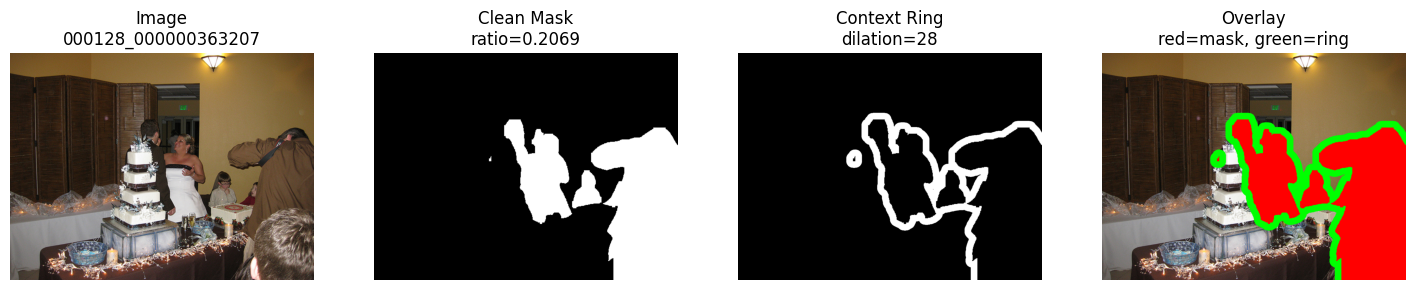

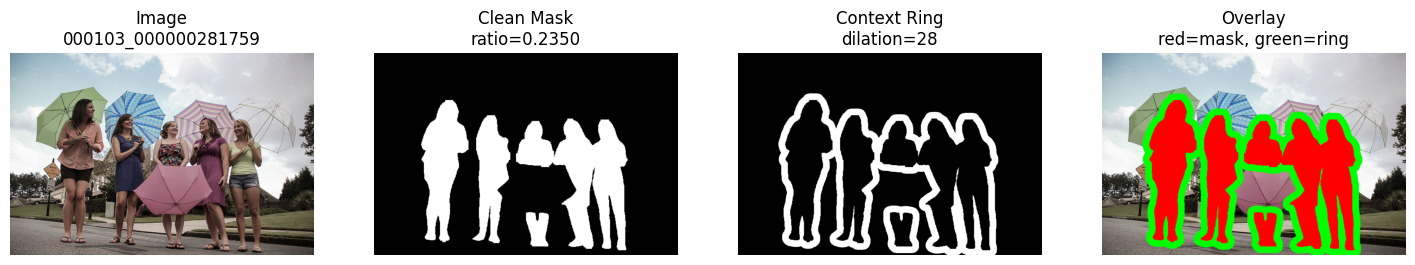

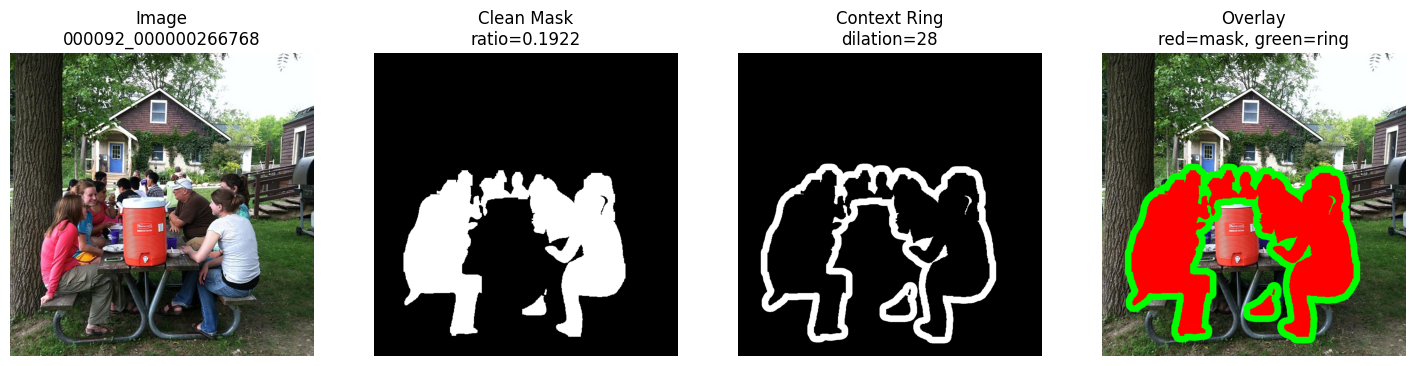

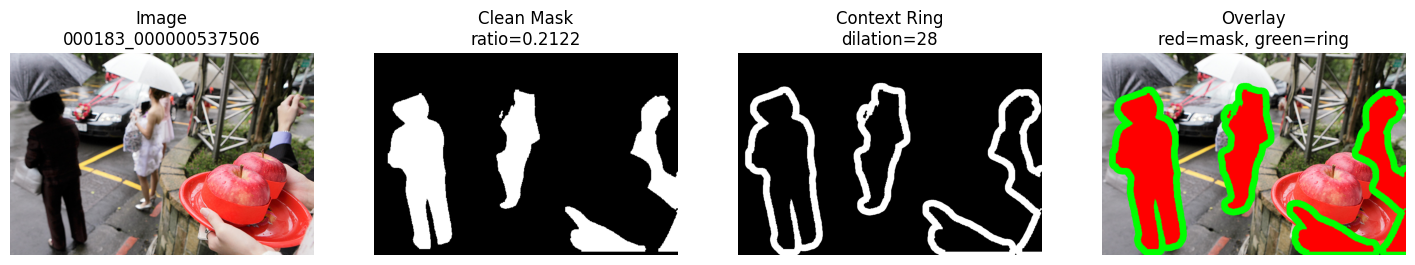

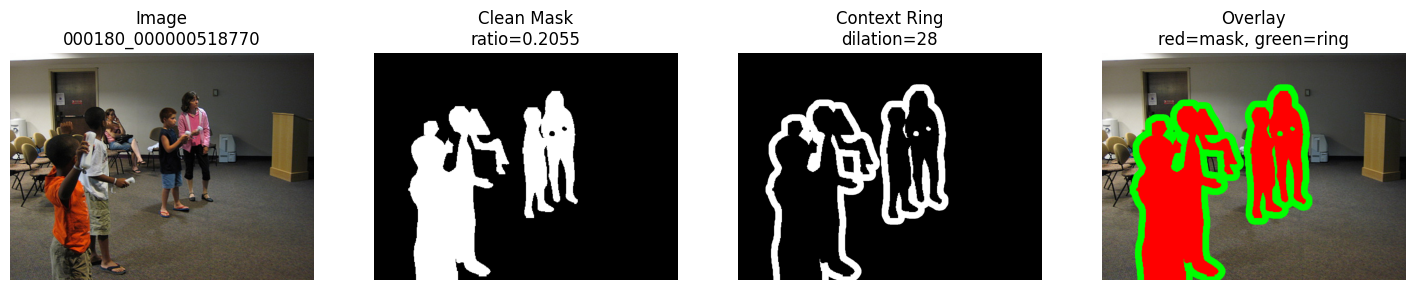

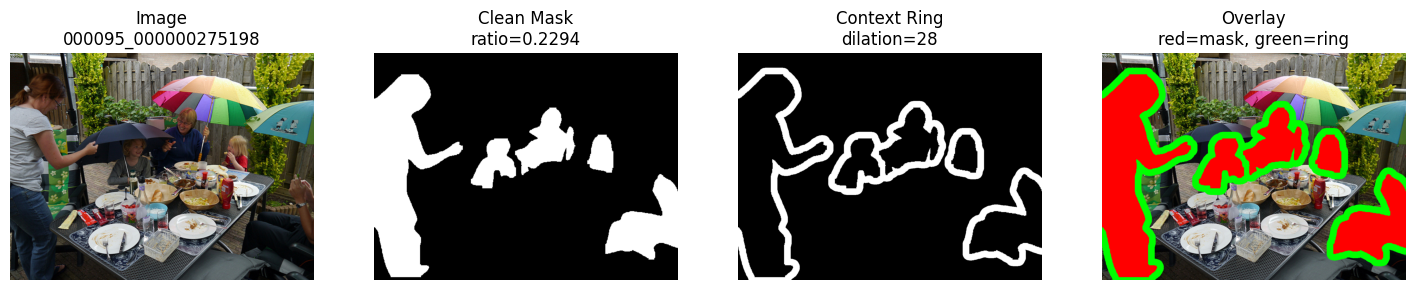

In [8]:
# ============================================================
# CELL 8: Visual check of preprocessing
# ============================================================

def show_preprocessed_examples(df, n=8, seed=42):
    if len(df) == 0:
        print("No processed samples found.")
        return

    sample_df = df.sample(min(n, len(df)), random_state=seed).reset_index(drop=True)

    for i in range(len(sample_df)):
        row = sample_df.iloc[i]
        image = np.array(Image.open(row["image_path"]).convert("RGB"))
        mask = np.array(Image.open(row["mask_path"]).convert("L"))
        ring = np.array(Image.open(row["ring_path"]).convert("L"))

        overlay = image.copy()
        overlay[mask > 0] = [255, 0, 0]
        overlay[ring > 0] = [0, 255, 0]

        plt.figure(figsize=(18, 5))

        plt.subplot(1, 4, 1)
        plt.imshow(image)
        plt.title(f"Image\n{row['id']}")
        plt.axis("off")

        plt.subplot(1, 4, 2)
        plt.imshow(mask, cmap="gray")
        plt.title(f"Clean Mask\nratio={row['mask_ratio']:.4f}")
        plt.axis("off")

        plt.subplot(1, 4, 3)
        plt.imshow(ring, cmap="gray")
        plt.title(f"Context Ring\ndilation={row['adaptive_dilation']}")
        plt.axis("off")

        plt.subplot(1, 4, 4)
        plt.imshow(overlay)
        plt.title("Overlay\nred=mask, green=ring")
        plt.axis("off")

        plt.show()

show_preprocessed_examples(df, n=CFG["num_preview_samples"])


In [9]:
# ============================================================
# CELL 9: Train / Val / Test split
# ============================================================

if len(df) == 0:
    raise ValueError("No processed data available. Please check your raw dataset and masks.")

ids = df["id"].tolist()

train_ids, temp_ids = train_test_split(
    ids,
    test_size=(1.0 - CFG["train_ratio"]),
    random_state=42,
    shuffle=True
)

relative_test_ratio = CFG["test_ratio"] / (CFG["val_ratio"] + CFG["test_ratio"])
val_ids, test_ids = train_test_split(
    temp_ids,
    test_size=relative_test_ratio,
    random_state=42,
    shuffle=True
)

split_map = {}
for x in train_ids:
    split_map[x] = "train"
for x in val_ids:
    split_map[x] = "val"
for x in test_ids:
    split_map[x] = "test"

df["split"] = df["id"].map(split_map)

split_csv = SPLIT_ROOT / "split_metadata.csv"
df.to_csv(split_csv, index=False)

for split_name in ["train", "val", "test"]:
    split_ids_path = SPLIT_ROOT / f"{split_name}.txt"
    split_ids = df[df["split"] == split_name]["id"].tolist()
    with open(split_ids_path, "w") as f:
        for item in split_ids:
            f.write(item + "\n")

print("Split saved to:", split_csv)
print(df["split"].value_counts())
display(df.groupby("split")["mask_ratio"].describe())


Split saved to: /content/drive/MyDrive/CSE498R_Final_Thesis/data/splits/split_metadata.csv
split
train    72
test     16
val      16
Name: count, dtype: int64


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
test,16.0,0.228902,0.067101,0.103887,0.196040,0.208744,0.285631,0.349595
train,72.0,0.242676,0.065080,0.088660,0.199808,0.247385,0.298604,0.343337
val,16.0,0.255482,0.067526,0.073914,0.223735,0.256560,0.297352,0.339889



# What comes next

After this notebook stage is complete, the next notebook should build:

## Stage 2 — Final thesis architecture
1. segmentation backbone  
2. mask refinement module  
3. adaptive context-aware removal mask  
4. global inpainting branch  
5. local refinement branch  
6. residual object feedback step  
7. evaluation metrics and ablations  

## Recommended final architecture
**YOLOv8-seg → Mask Refinement → Adaptive Context Ring → LaMa Global Branch → Local Crop Refinement → Residual Detection Feedback**

That is the stronger direction for your final thesis.

If this preprocessing notebook runs well on your data, the next step is to code the **training/inference notebook**.
